In [1]:
from cuda_cqed.sim import Sim
# import gpu_odes.HatGPUODE_D
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Qt5Agg')
%matplotlib inline

In [60]:
pi = np.pi

sim = Sim(use_complex=True)

drive_dBm_i = -40
drive_dBm_f = 20
drive_dBm_pts = 61
photon_energy = 5e9*6.62e-34

ATT =  100

power_i = 1e-3*10**((drive_dBm_i-ATT)/10)
power_f = 1e-3*10**((drive_dBm_f-ATT)/10)

amplR_i = np.sqrt((power_i)/photon_energy)
amplR_f = np.sqrt((power_f)/photon_energy)

sim.add_param('sqrtka_ext', np.sqrt(10e6*2*pi)) # in MHz
sim.add_param('ka_int', 100e6*2*pi) # in MHz
sim.add_param('g4', 0.0e6 * 2 * np.pi)
sim.add_param('gr', 1e6 * 2 * np.pi)
sim.add_paramsweep('log10_amplR', np.log10(amplR_i), np.log10(amplR_f), drive_dBm_pts)
sim.add_param('wa', 5.0e9*2*pi)
sim.add_paramsweep('wR', 4.8e9 * 2 * np.pi, 5.2e9 * 2 * np.pi, 1001, is_excitation=True)
sim.add_param('rampR', 1e-9)
sim.add_param('startR', 5e-9)
sim.add_param('stopR', 300e-9)
sim.add_param('phaseR', 0)

Rpulse = sim.make_pulse('wR', '10**(log10_amplR)', 'phaseR', 'startR', 'stopR', 'rampR')

sim.add_EOM('ain', Rpulse)

sim.add_EOM('a', '-1j*wa*a - ain*sqrtka_ext - (sqrtka_ext**2 + ka_int)/2*a - 1j*a*g4*abs(a)**2 ')
sim.set_solve_type('decimate')

sim.specify_time(20, 500, d_factor=1)

sim.validate()

print(amplR_f)

Simulation validation success!
1738144.9986274957


Simulation validation success!
Running CPU quick solve...
...finished CPU quick solve!


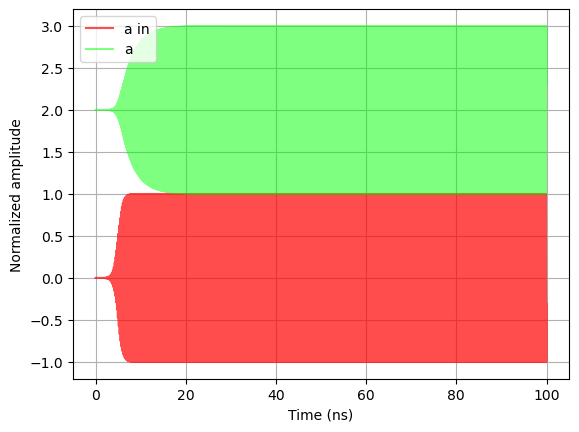

In [61]:
x, t = sim.quick_trace()

plt.figure(1)
plt.clf()
plt.plot(t*1e9, x[0,:]/np.max(x[0,:]),color=(1,0,0,0.7),label='a in')
plt.plot(t*1e9, x[2,:]/np.max(x[2,:])+2,color=(0,1,0,0.5),label='a')
plt.xlabel('Time (ns)')
plt.ylabel('Normalized amplitude')
plt.legend()
plt.grid()
plt.show()

In [62]:
I, Q, t = sim.solve()

Simulation validation success!
Running GPU solve...


100%|███████████████████████████████████████████████████████████████████████████| 10000/10000 [00:15<00:00, 661.03it/s]


 
...finished GPU solve!


In [63]:
Id = I.copy()
Qd = Q.copy()
td = t.copy()

ain = Id[0,:]+1j*Qd[0,:]
a = Id[2,:]+1j*Qd[2,:]

aout = ain + sim.param_dict['sqrtka_ext']*a

C:\Users\boris\AppData\Local\Temp\ipykernel_30636\716985255.py:1: RuntimeWarning: invalid value encountered in divide
  S11 = (aout/ain)[:,:,-1]


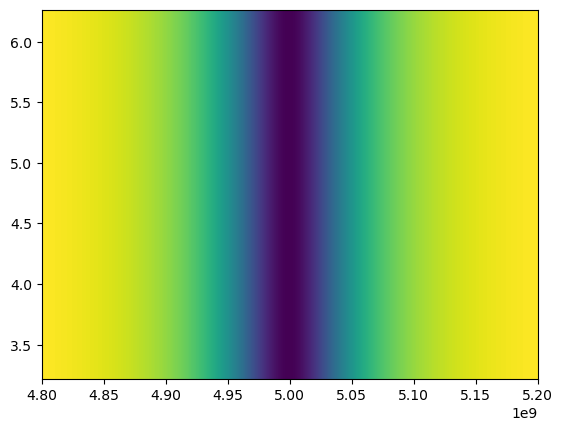

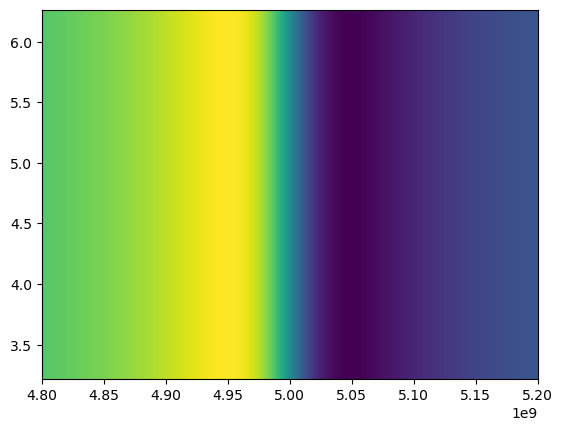

In [64]:
S11 = (aout/ain)[:,:,-1]

wR = sim.paramsweep_dict['wR']/(2*np.pi)
amplR = sim.paramsweep_dict['log10_amplR']

plt.pcolor(wR, amplR, np.abs(S11))
plt.show()
plt.pcolor(wR, amplR, np.angle(S11))
plt.show()

In [67]:
nbar_th = 4*power_f/(10e6*2*np.pi*photon_energy)
print(nbar_th)

192332.25751286448


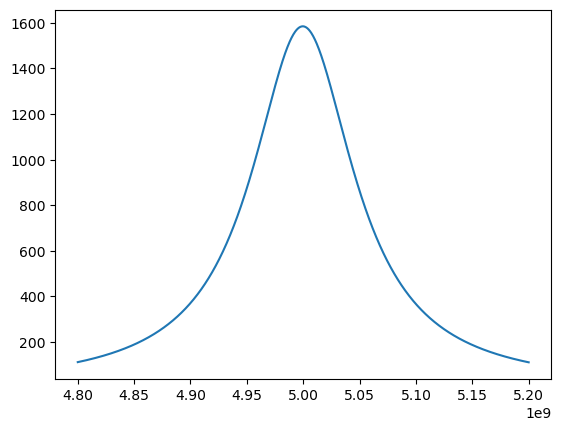

1583.988098476466


In [66]:
plt.plot(wR, np.abs(a[-1,:,-1])**2)
plt.show()
print(np.max(np.abs(a[-1,:,-1])**2))